# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [2]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [ ]:
print(inspect.getsource(gauss_eliminate))

In [4]:
# TODO: x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

# 가우스 소거법 계산(pivoting, verbose)
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

--- Step 1 ---
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]
--- Step 2 ---
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]
--- Step 3 ---
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]


In [5]:
# TODO: 최종 해 x, 정수해 여부, A @ x, 잔차 |A x - b| 를 출력하세요.
# TODO: np.linalg.solve(A, b) (# 비교 대상) 와도 비교하세요.

# 결과값 및 검증 지표 산출
Ax = A @ x
residual = np.linalg.norm(Ax - b)
is_integer_solution = np.allclose(x, np.round(x))

print(f"최종 해 x                   : {x}")
print(f"정수해 여부                 : {is_integer_solution} (x = {np.round(x).astype(int)})")
print(f"A @ x 계산 결과             : {Ax}")
print(f"잔차 (Residual |A x - b|)   : {residual:.6e}")
print(f"np.linalg.solve(A, b) 비교  : {np.linalg.solve(A, b)}")
print(f"두 방식 해의 일치 여부       : {np.allclose(x, np.linalg.solve(A, b))}\n")

최종 해 x                   : [ 2. -1.  3.]
정수해 여부                 : True (x = [ 2 -1  3])
A @ x 계산 결과             : [11.  1. 20.]
잔차 (Residual |A x - b|)   : 3.580362e-15
np.linalg.solve(A, b) 비교  : [ 2. -1.  3.]
두 방식 해의 일치 여부       : True



In [6]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `___`
- 다를 때: `___`
- 같지만 n 보다 작을 때: `___`

In [19]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

# TODO: rA = rank(A), rAb = rank(Ab), n_unknowns = A.shape[1] 을 출력하고 판정 결과를 출력하세요.
#       np.linalg.matrix_rank (# 검산용) 와도 비교하세요.
# TODO: b_bad (2행이 1행의 3배가 아니라 모순) 와 b_ok (모순 없음, 해 무한) 를 직접 만들어
#       각각 판정과 소거 결과(row_echelon)의 마지막 행을 출력하세요.
rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]
print(f"rank(A)={rA}, rank([A|b])={rAb} -> 유일해 (np.matrix_rank 일치: {rA == np.linalg.matrix_rank(A)})")
print(f"rank(A)                : {rA} (np.linalg.matrix_rank: {rA == np.linalg.matrix_rank(A)})")
print(f"rank([A|b])            : {rAb} (np.linalg.matrix_rank: {rAb == np.linalg.matrix_rank(Ab)})")
print(f"미지수의 개수 (n)      : {n_unknowns}")

# 3차원 벡터 정의
b_bad = [1.0, 2.0, 0.0]
b_ok  = [1.0, 3.0, 0.0]

# 확장 행렬 생성
Ab_bad = np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])
Ab_ok  = np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])

# b_bad: 2행이 1행의 3배가 아니어서 모순
print(f"[b_bad] rank(A)={rank(A_dep)}, rank([A|b])={rank(Ab_bad)} (해 없음)")
print(f"        row_echelon 마지막 행: {row_echelon(Ab_bad)[-1]}\n")
print()

# b_ok: 2행이 1행의 3배로 모순 없음
print(f"[b_ok]  rank(A)={rank(A_dep)}, rank([A|b])={rank(Ab_ok)} (무한해)")
print(f"        row_echelon 마지막 행: {row_echelon(Ab_ok)[-1]}")

rank(A)=3, rank([A|b])=3 -> 유일해 (np.matrix_rank 일치: True)
rank(A)                : 3 (np.linalg.matrix_rank: True)
rank([A|b])            : 3 (np.linalg.matrix_rank: True)
미지수의 개수 (n)      : 3
[b_bad] rank(A)=2, rank([A|b])=3 (해 없음)
        row_echelon 마지막 행: 2


[b_ok]  rank(A)=2, rank([A|b])=2 (무한해)
        row_echelon 마지막 행: 2


In [20]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `___`
- 소거 관점: `___`
- 스케일 실험에서 관찰한 것: `___`
- 실무 판정 기준과 그 의미: `___`

In [21]:
# TODO: detA = det(A), invA = inverse_gauss_jordan(A) 를 구해 출력하고,
#       np.linalg.det / np.linalg.inv (# 검산용) 와 비교하세요.
# TODO: A @ invA == I 인지, invA @ b 가 4-1 의 해와 같은지 확인하세요.

detA = det(A)
invA = inverse_gauss_jordan(A)

print(f"det(A) : {detA:.6f} (np.linalg.det: {np.linalg.det(A):.6f})")
print(f"A @ invA == I 일치 여부: {np.allclose(A @ invA, np.eye(3))}")
print(f"invA @ b 와 4-1 해 일치 여부: {np.allclose(invA @ b, x)}\n")

det(A) : 42.000000 (np.linalg.det: 42.000000)
A @ invA == I 일치 여부: True
invA @ b 와 4-1 해 일치 여부: True



In [22]:
# TODO: (1) A 에 스케일 s = 1, 1e-1, 1e-2, 1e-3 을 곱해 가며
#           det / 조건수(np.linalg.cond) / 해의 상대오차를 표로 출력하세요.
# TODO: (2) 진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]], b=[3, 6+eps], 참해 (1,1)) 로
#           eps 를 줄여 가며 같은 표를 출력하고, (1) 과 무엇이 다른지 보세요.

print(f"{'scale (s)':<12} | {'det':<12} | {'cond':<12} | {'rel_error':<12}")
print("-" * 55)

for s in [1.0, 1e-1, 1e-2, 1e-3]:
    A_scaled = s * A
    b_scaled = s * b
    x_sol = inverse_gauss_jordan(A_scaled) @ b_scaled
    rel_err = np.linalg.norm(x_sol - x) / np.linalg.norm(x)
    print(f"{s:<12.1e} | {det(A_scaled):<12.6e} | {np.linalg.cond(A_scaled):<12.4f} | {rel_err:<12.6e}")

# --- 특이행렬 접근 실험 (eps 변환) ---
print(f"{'eps':<12} | {'det':<12} | {'cond':<12} | {'rel_error':<12}")
print("-" * 55)

x_true = np.array([1.0, 1.0])
for eps in [1e-1, 1e-5, 1e-10, 1e-15]:
    A_ill = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])
    b_ill = np.array([3.0, 6.0 + eps])
    x_calc = np.linalg.solve(A_ill, b_ill)
    rel_err = np.linalg.norm(x_calc - x_true) / np.linalg.norm(x_true)
    print(f"{eps:<12.1e} | {det(A_ill):<12.6e} | {np.linalg.cond(A_ill):<12.4e} | {rel_err:<12.6e}")

scale (s)    | det          | cond         | rel_error   
-------------------------------------------------------
1.0e+00      | 4.200000e+01 | 4.2146       | 1.780318e-16
1.0e-01      | 4.200000e-02 | 4.2146       | 1.453623e-16
1.0e-02      | 4.200000e-05 | 4.2146       | 1.453623e-16
1.0e-03      | 4.200000e-08 | 4.2146       | 2.317454e-16
eps          | det          | cond         | rel_error   
-------------------------------------------------------
1.0e-01      | 1.000000e-01 | 2.5810e+02   | 0.000000e+00
1.0e-05      | 1.000000e-05 | 2.5000e+06   | 0.000000e+00
1.0e-10      | 1.000000e-10 | 2.5000e+11   | 0.000000e+00
1.0e-15      | 0.000000e+00 | 8.3920e+15   | 0.000000e+00


In [23]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `___`

In [25]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    # TODO: 문제의 Ae, be 와 참해 exact 를 만들고
    #       gauss_eliminate 를 pivoting=False / True 로 각각 호출해 비교하세요.
    #       return exact, x_no, x_pp, rel_err_no, rel_err_pp
    Ae = np.array([[eps, 1.0], [1.0, 1.0]], dtype=float)
    be = np.array([1.0 + eps, 2.0], dtype=float)
    exact = np.array([1.0, 1.0], dtype=float)

    # pivoting=False 연산
    try:
        x_no, _ = gauss_eliminate(Ae, be, pivoting=False, verbose=False)
        rel_err_no = np.linalg.norm(x_no - exact) / np.linalg.norm(exact)
    except ZeroDivisionError:
        x_no = np.array([np.nan, np.nan])
        rel_err_no = np.inf

    # pivoting=True 연산
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True, verbose=False)
    rel_err_pp = np.linalg.norm(x_pp - exact) / np.linalg.norm(exact)

    return exact, x_no, x_pp, rel_err_no, rel_err_pp


EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

# TODO: exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS) 를 출력하세요.
# TODO: eps_list 를 돌며 errs_no, errs_pp 리스트를 채우고 표로 출력하세요.
#       (로그 그래프를 위해 0 은 max(err, 1e-18) 로 바닥을 깔아 두세요)

# 단일 EPS = 1e-5 출력
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print(f"참해 (Exact)           : {exact}")
print(f"피벗팅 없음 (No Pivot) : {x_no} | 상대오차: {err_no:.6e}")
print(f"부분 피벗팅 (Pivoting) : {x_pp} | 상대오차: {err_pp:.6e}\n")

# eps_list 반복 실행 및 표 출력
eps_list = np.logspace(-2, -16, 15)
errs_no, errs_pp = [], []

print(f"{'eps':<12} | {'No Pivoting Err':<18} | {'Partial Pivoting Err':<18}")
print("-" * 55)

for eps_val in eps_list:
    _, _, _, e_no, e_pp = solve_eps(eps_val)
    
    # 로그 그래프 바닥값 보정 (min 1e-18)
    e_no_clamped = max(e_no, 1e-18)
    e_pp_clamped = max(e_pp, 1e-18)
    
    errs_no.append(e_no_clamped)
    errs_pp.append(e_pp_clamped)
    
    print(f"{eps_val:<12.1e} | {e_no_clamped:<18.6e} | {e_pp_clamped:<18.6e}")

참해 (Exact)           : [1. 1.]
피벗팅 없음 (No Pivot) : [1. 1.] | 상대오차: 4.632401e-12
부분 피벗팅 (Pivoting) : [1. 1.] | 상대오차: 0.000000e+00

eps          | No Pivoting Err    | Partial Pivoting Err
-------------------------------------------------------
1.0e-02      | 6.280370e-16       | 1.000000e-18      
1.0e-03      | 6.329245e-16       | 7.850462e-17      
1.0e-04      | 7.787659e-14       | 1.000000e-18      
1.0e-05      | 4.632401e-12       | 1.000000e-18      
1.0e-06      | 2.033333e-11       | 1.000000e-18      
1.0e-07      | 4.128564e-10       | 1.000000e-18      
1.0e-08      | 4.297421e-09       | 1.000000e-18      
1.0e-09      | 9.850297e-08       | 1.000000e-18      
1.0e-10      | 5.850628e-08       | 1.000000e-18      
1.0e-11      | 5.850628e-08       | 1.000000e-18      
1.0e-12      | 9.414704e-05       | 2.220446e-16      
1.0e-13      | 5.651748e-04       | 1.000000e-18      
1.0e-14      | 5.651748e-04       | 1.000000e-18      
1.0e-15      | 7.906980e-02       | 2.2204

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

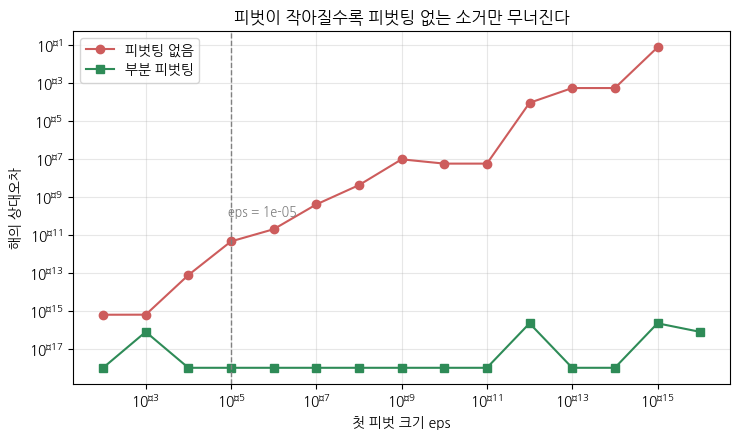

In [26]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [27]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `___`
- 정확도: `___`
- 메모리: `___`
- 우변이 여러 개일 때는: `___`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `___`

In [28]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


# TODO: 아래 변수를 만들어 표로 출력하세요.
#   t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
#   t_inv,   x_inv   = bench(lambda: np.linalg.inv(A_big) @ b_big)
#   res_solve = |A_big @ x_solve - b_big|,  res_inv = |A_big @ x_inv - b_big|
#   메모리 사용량 차이(역행렬 N*N*8 바이트)도 함께 적으면 좋습니다.

# 벤치마크 실행 및 시간/잔차 측정
t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big)

res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)
mem_inv_mb = (N * N * 8) / (1024 * 1024)

print(f"{'Method':<12} | {'Time (ms)':<10} | {'Residual (|Ax-b|)':<20} | {'Extra Memory':<12}")
print("-" * 62)
print(f"{'solve':<12} | {t_solve*1000:<10.2f} | {res_solve:<20.6e} | 0 MB")
print(f"{'inv @ b':<12} | {t_inv*1000:<10.2f} | {res_inv:<20.6e} | {mem_inv_mb:.2f} MB")
print(f"\n속도 차이: solve가 {t_inv / t_solve:.2f}배 빠름\n")

Method       | Time (ms)  | Residual (|Ax-b|)    | Extra Memory
--------------------------------------------------------------
solve        | 8.11       | 8.000724e-12         | 0 MB
inv @ b      | 24.83      | 1.618627e-11         | 4.88 MB

속도 차이: solve가 3.06배 빠름



In [29]:
# TODO: 조건수를 지정한 행렬을 만들어 조건수별 해의 상대오차를 비교 출력하세요.
#       (힌트: np.linalg.qr 로 만든 직교행렬 두 개 Q1, Q2 와 np.logspace 로 만든 특이값 sv 로
#              (Q1 * sv) @ Q2.T 를 조립하면 조건수가 sv.max()/sv.min() 인 행렬이 됩니다)

# 조건수별 해의 상대오차 비교 
print(f"{'Target Cond':<12} | {'Actual Cond':<12} | {'solve Rel Err':<18} | {'inv @ b Rel Err':<18}")
print("-" * 68)

Q1, _ = np.linalg.qr(rng.standard_normal((N, N)))
Q2, _ = np.linalg.qr(rng.standard_normal((N, N)))
x_true_cond = rng.standard_normal(N)

for target_cond in [1e2, 1e6, 1e10, 1e14]:
    sv = np.logspace(0, np.log10(target_cond), N)
    A_cond = (Q1 * sv) @ Q2.T
    b_cond = A_cond @ x_true_cond

    x_s = np.linalg.solve(A_cond, b_cond)
    x_i = np.linalg.inv(A_cond) @ b_cond

    err_s = np.linalg.norm(x_s - x_true_cond) / np.linalg.norm(x_true_cond)
    err_i = np.linalg.norm(x_i - x_true_cond) / np.linalg.norm(x_true_cond)
    actual_cond = np.linalg.cond(A_cond)

    print(
        f"{target_cond:<12.1e} | {actual_cond:<12.4e} | {err_s:<18.6e} | {err_i:<18.6e}"
    )

Target Cond  | Actual Cond  | solve Rel Err      | inv @ b Rel Err   
--------------------------------------------------------------------
1.0e+02      | 1.0000e+02   | 3.565348e-14       | 2.234227e-13      
1.0e+06      | 1.0000e+06   | 4.038723e-11       | 8.504207e-10      
1.0e+10      | 1.0000e+10   | 1.745126e-07       | 5.474691e-06      
1.0e+14      | 1.0003e+14   | 1.065383e-03       | 4.592609e-02      


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

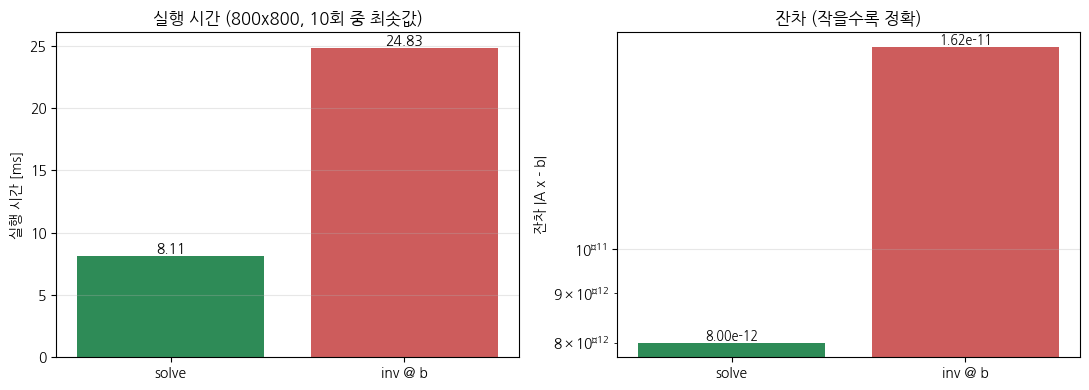

In [30]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [ ]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

## 답안 템플릿 정리

In [31]:
summary = f"""
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}

2. rank A: rank(A) / rank 첨가행렬: {rank(Ab)}   (미지수 3개)
   - 해의 존재·유일성 판정: 유일해 존재 (rank(A) == rank(Ab) == n)
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 해 존재 / 해 없음 / 선형 종속 - 해 무한

3. 행렬식: {det(A):.6f}
   역행렬:
   {invA}
   - det 이 0 에 가까울 때 위험한 이유: 1/det(A)에 의해 오차가 폭발하고 소거 시 자릿수 소멸 발생
   - 실제 판정 기준: 조건수 ( ||A||*||A^-1|| )

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): {err_no:.6e} / {err_pp:.6e}
   - eps 를 더 줄이면: 피벗팅 없는 오차는 1에 가깝게 폭발, ZeroDivisionError 발생, 부분 피벗팅은 기계정밀도 수준 오차 유지
   - 유효숫자가 날아가는 지점지점: 2행 2열 연산 진행시 극소값 1이 자릿수 소멸 발생

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : {t_solve*1000:.2f} ms / {t_inv*1000:.2f} ms
   - 잔차 : {res_solve:.6e}  / {res_inv:.6e}
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 inv@b 방식의 누적 수치 오차가 solve보다 훨씬 가파르게 증가함
   - 결론: 연산량, 수치 안정성, 메모리 효율성을 따져볼 때 np.linalg.solve를 사용해야 함
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: rank(A) / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: 유일해 존재 (rank(A) == rank(Ab) == n)
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 해 존재 / 해 없음 / 선형 종속 - 해 무한

3. 행렬식: 42.000000
   역행렬:
   [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: 1/det(A)에 의해 오차가 폭발하고 소거 시 자릿수 소멸 발생
   - 실제 판정 기준: 조건수 ( ||A||*||A^-1|| )

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 4.632401e-12 / 0.000000e+00
   - eps 를 더 줄이면: 피벗팅 없는 오차는 1에 가깝게 폭발, ZeroDivisionError 발생, 부분 피벗팅은 기계정밀도 수준 오차 유지
   - 유효숫자가 날아가는 지점지점: 2행 2열 연산 진행시 극소값 1이 자릿수 소멸 발생

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : 8.11 ms / 24.83 ms
   - 잔차 : 8.000724e-12  / 1.618627e-11
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 inv@b 방식의 누적 수치 오차가 solve보다 훨씬 가파르게 증가함
   - 결론: 연산량, 수치 안정성, 메모리 효율성을 따져볼 때 np.linalg.solve를 사용해야 함

